**Deep Learning Assignment 3**

Assignment No. 3 : Write a program to implement k-Nearest Neighbour algorithm to classify the iris data set. Print both correct and wrong predictions. Python ML library classes can be used for this problem.



Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Correct Predictions:
Actual: versicolor | Predicted: versicolor
Actual: setosa | Predicted: setosa
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor
Actual: setosa | Predicted: setosa
Actual: versicolor | Predicted: versicolor
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor
Actual: virginica | Predicted: virginica
Actual: setosa | Predicted: setosa
Actual: setosa | P

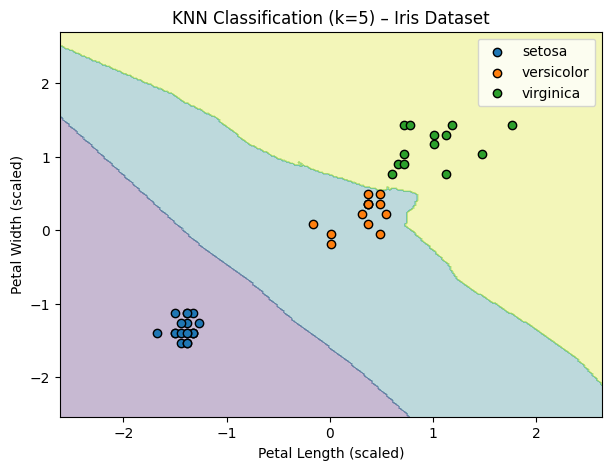

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Iris dataset
iris = load_iris()
X = iris.data[:, 2:4]   # Petal Length & Petal Width (for visualization)
y = iris.target

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 5. Predictions
y_pred = knn.predict(X_test)

# --------------------------------------------------
# 6. Evaluation Metrics
# --------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# --------------------------------------------------
# 7. Print Correct and Wrong Predictions
# --------------------------------------------------
print("\nCorrect Predictions:")
for i in range(len(y_test)):
    if y_test[i] == y_pred[i]:
        print(f"Actual: {iris.target_names[y_test[i]]} | Predicted: {iris.target_names[y_pred[i]]}")

print("\nWrong Predictions:")
for i in range(len(y_test)):
    if y_test[i] != y_pred[i]:
        print(f"Actual: {iris.target_names[y_test[i]]} | Predicted: {iris.target_names[y_pred[i]]}")

# --------------------------------------------------
# 8. Visualization – Decision Boundary
# --------------------------------------------------
h = 0.02
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3)

# Scatter plot of test points
for class_value, color, label in zip([0, 1, 2],
                                     ['red', 'green', 'blue'],
                                     iris.target_names):
    plt.scatter(
        X_test[y_test == class_value, 0],
        X_test[y_test == class_value, 1],
        label=label,
        edgecolor='k'
    )

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("KNN Classification (k=5) – Iris Dataset")
plt.legend()
plt.show()
